# scikit-learn Bootcamp — W2, Day 16
```
##### Trees & Forests Applied — Health Domain
##### sklearn built-in heart disease dataset · feature importance · tree visualisation
##### Q1 — EDA: Heart Disease dataset (sklearn built-in)
##### Q2 — Decision Tree: tune max_depth, visualise the tree
##### Q3 — Random Forest: feature importance, OOB score
##### Q4 — ExtraTreesClassifier vs RandomForest — speed and accuracy
##### Q5 — Partial dependence plots for top 3 features
```

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, classification_report
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid'); np.random.seed(420)

In [ ]:
# Cleveland Heart Disease — direct from UCI via pandas (no auth, no API)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df = pd.read_csv(url, header=None, names=cols, na_values='?').dropna()
df['target'] = (df['target'] > 0).astype(int)  # 0=no disease, 1=disease

X = df.drop(columns='target')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=420, stratify=y
)
print('Shape:', df.shape, '| Heart disease rate:', y.mean().round(3))
display(df.head())

Shape: (297, 14) | Heart disease rate: 0.461


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


---
### Q1 — EDA
```
# (a) Class balance.
# (b) Feature distributions by target class (KDE grid).
# (c) Correlation heatmap.
# (d) Box plots: top 3 predictors by target.
```

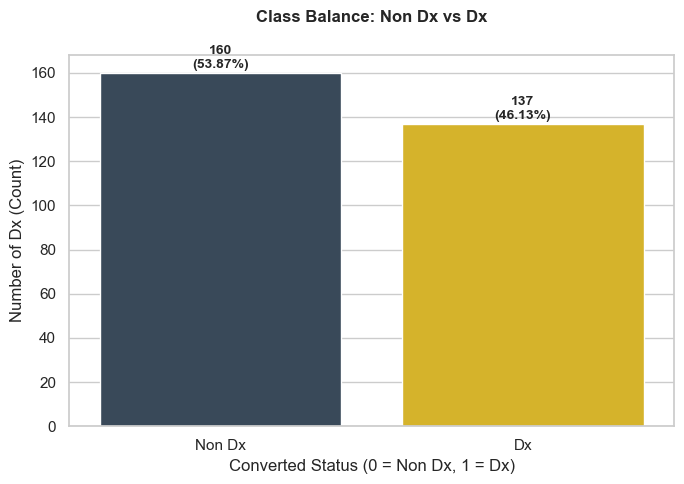

In [9]:
# (a) Class balance.

plt.figure(figsize=(7, 5))

# Use countplot to display the explicit distribution of records
# We assign individual colors to the class categories
ax = sns.countplot(
    data=df,
    x='target',
    palette={'0': '#34495e', '1': '#f1c40f'}
)

# Added Loop to Label % for each class
total_samples = len(df)
for bar in ax.patches:
    count = int(bar.get_height())
    percentage = (count / total_samples) * 100
    
    # Label text showing both raw count and percentage
    label_text = f"{count}\n({percentage:.2f}%)"
    
    # Position text slightly above the top center of each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + 1,  # Offset so text doesn't overlap the top of the bar
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Final aesthetic treatments
plt.title('Class Balance: Non Dx vs Dx', fontsize=12, fontweight='bold', pad=24)
plt.xlabel('Converted Status (0 = Non Dx, 1 = Dx)')
plt.ylabel('Number of Dx (Count)')
#plt.ylim(0,200)
plt.xticks([0, 1], ['Non Dx', 'Dx'])
plt.tight_layout()
plt.show()

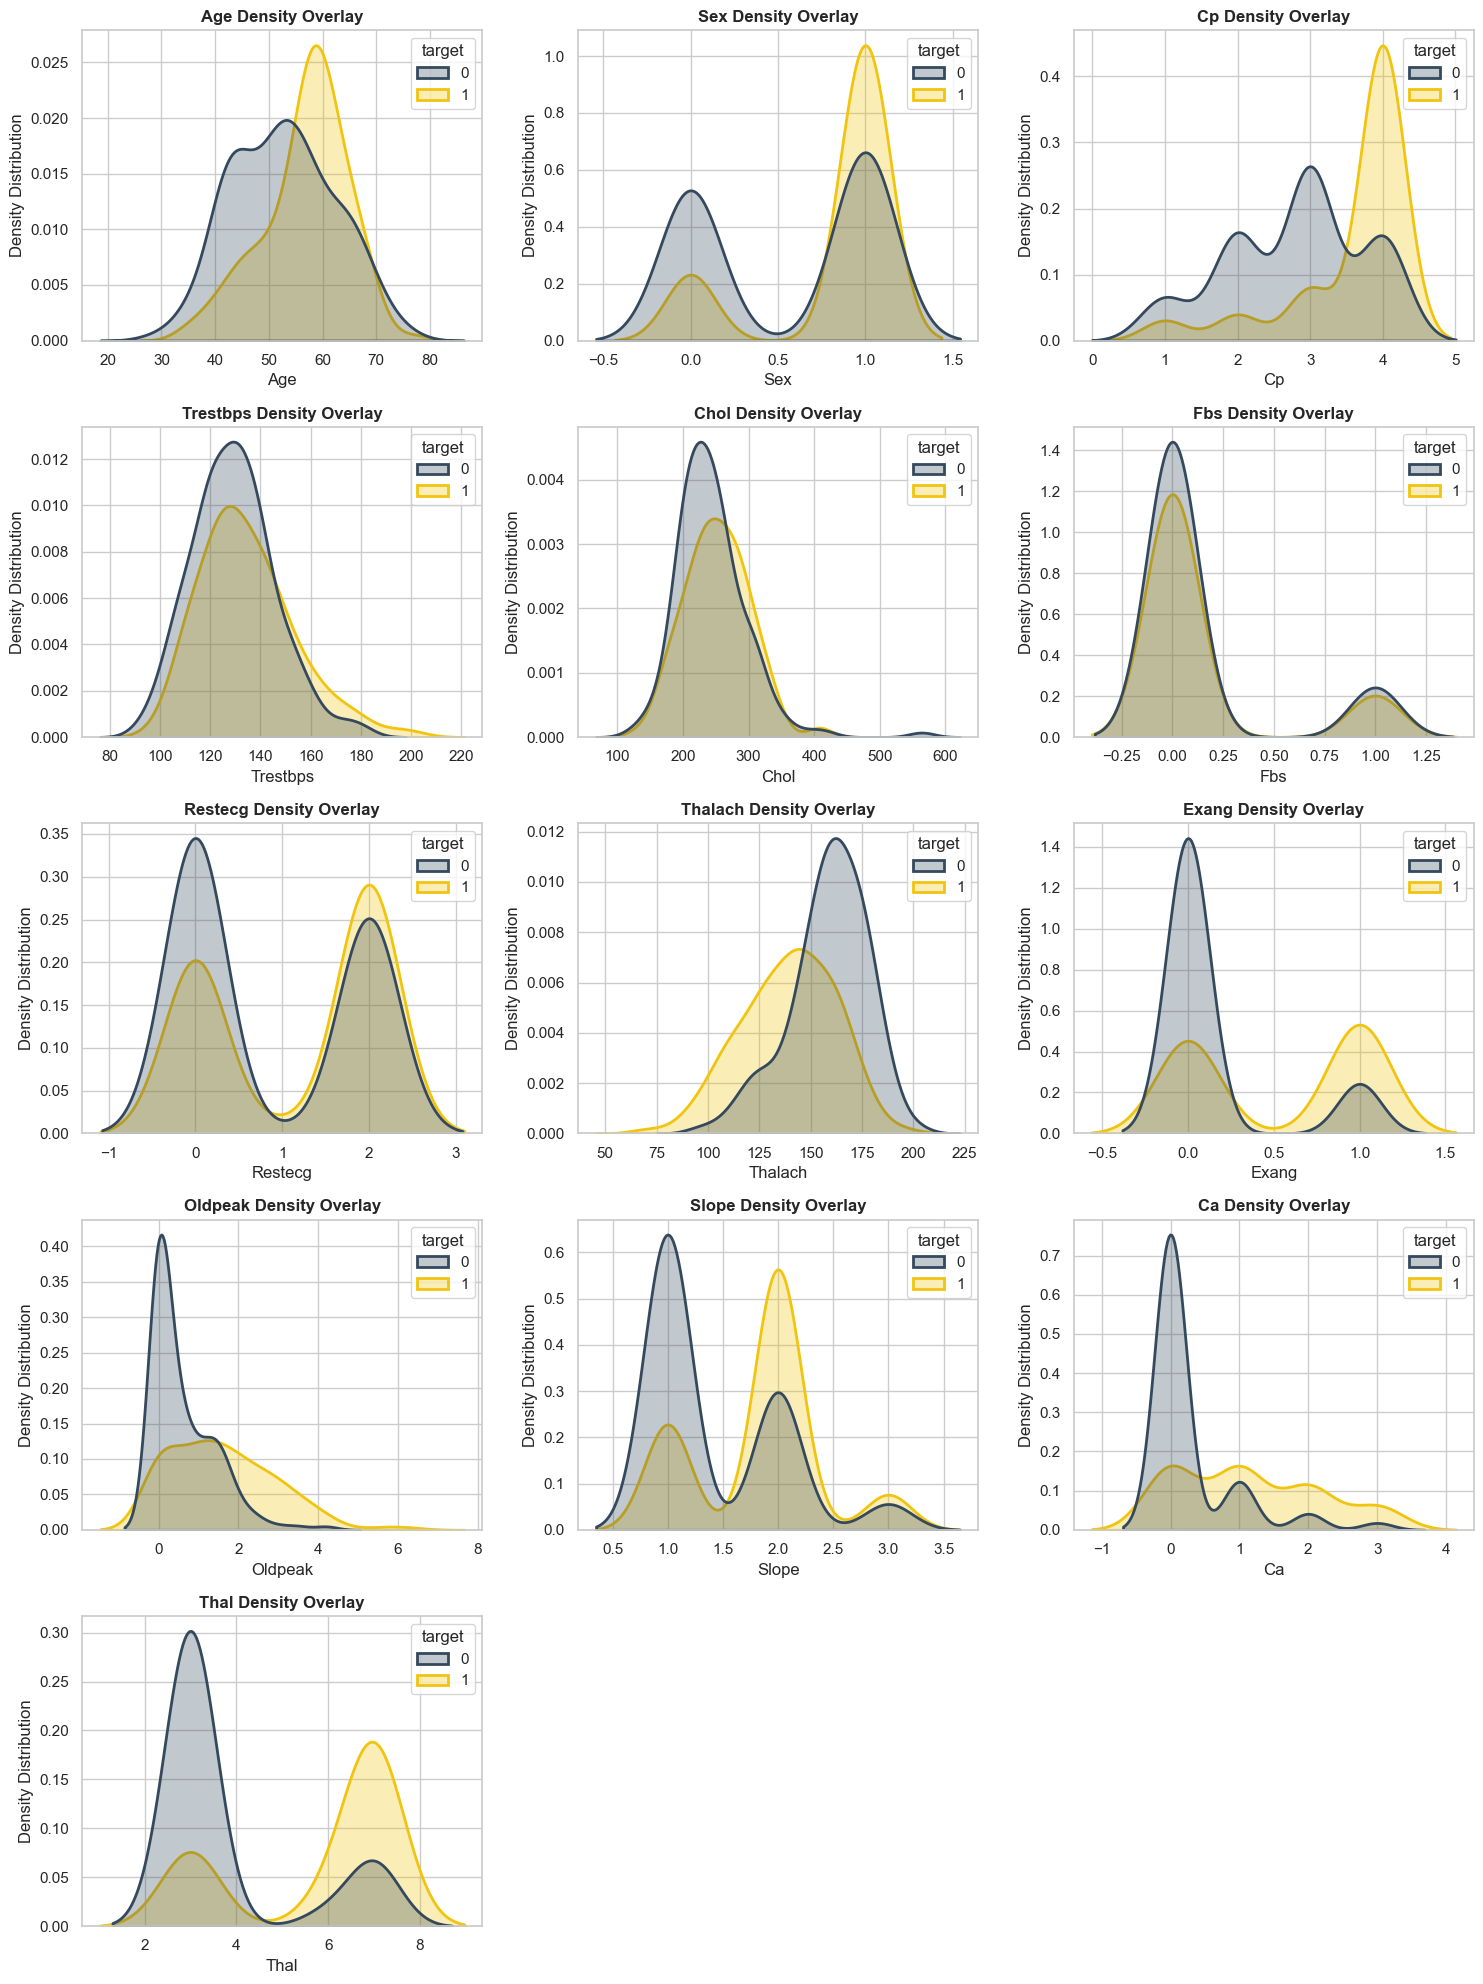

In [19]:
# (b) Feature distributions by target class (KDE grid).

import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your dataset and columns
features = df.drop(columns=['target']).columns.to_list()
target_column = "target"  # The column used for color coding (hue)

# 2. Automatically calculate grid dimensions
num_plots = len(features)
num_cols = 3  # Set how many columns per row
num_rows = math.ceil(num_plots / num_cols)

# 3. Dynamic figure sizing 
plt.figure(figsize=(15, 4 * num_rows))

# 4. Generate the plots dynamically
for i, col in enumerate(features, start=1):
    plt.subplot(num_rows, num_cols, i)

    # Clean up column names for titles/labels (e.g., 'time_on_site' -> 'Time On Site')
    clean_title = col.replace("_", " ").title()

    sns.kdeplot(
        data=df,  # Change this to your new DataFrame variable
        x=col,
        hue=target_column,
        fill=True,
        alpha=0.3,
        linewidth=2,
        palette={0: "#34495e", 1: "#f1c40f"},  # Change keys if your target isn't 0 and 1
    )

    plt.title(f"{clean_title} Density Overlay", fontweight="bold")
    plt.xlabel(clean_title)
    plt.ylabel("Density Distribution")

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

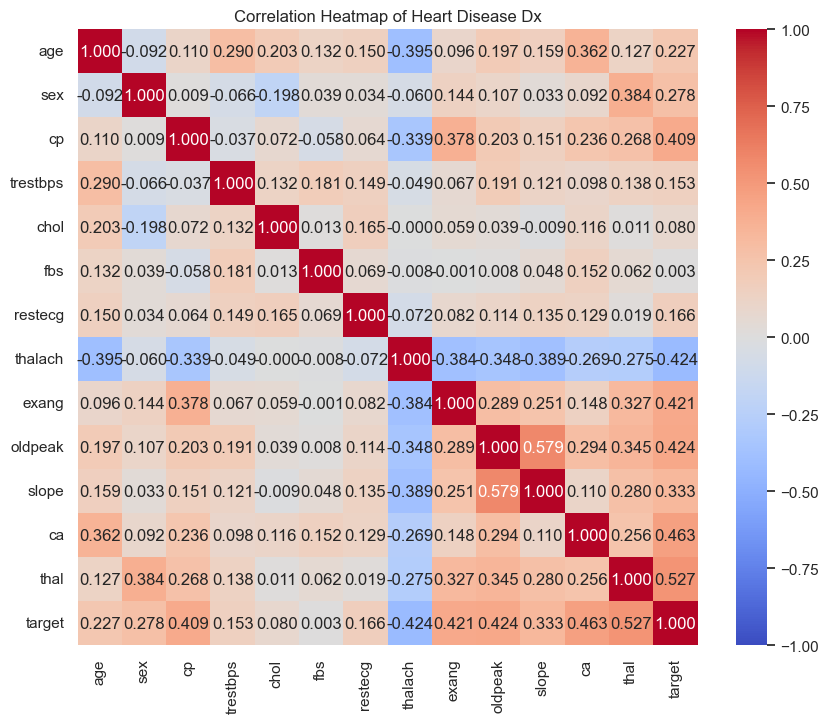


Linear Correlation with booking:
target      1.000000
thal        0.526640
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: target, dtype: float64

******* Top 3 Predictor by Target *******
thal       0.526640
ca         0.463189
oldpeak    0.424052
Name: target, dtype: float64


In [29]:
# (c) Correlation heatmap.

# 1. Keep target, but drop the leaking binary indicator column
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix including the target
corr_matrix = numeric_df.corr()

# 3. Render the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Heart Disease Dx')
plt.show()

# 4. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with booking:")
print(corr_matrix['target'].sort_values(ascending=False))
print('\n******* Top 3 Predictor by Target *******')
print(corr_matrix['target'].sort_values(ascending=False)[1:4])


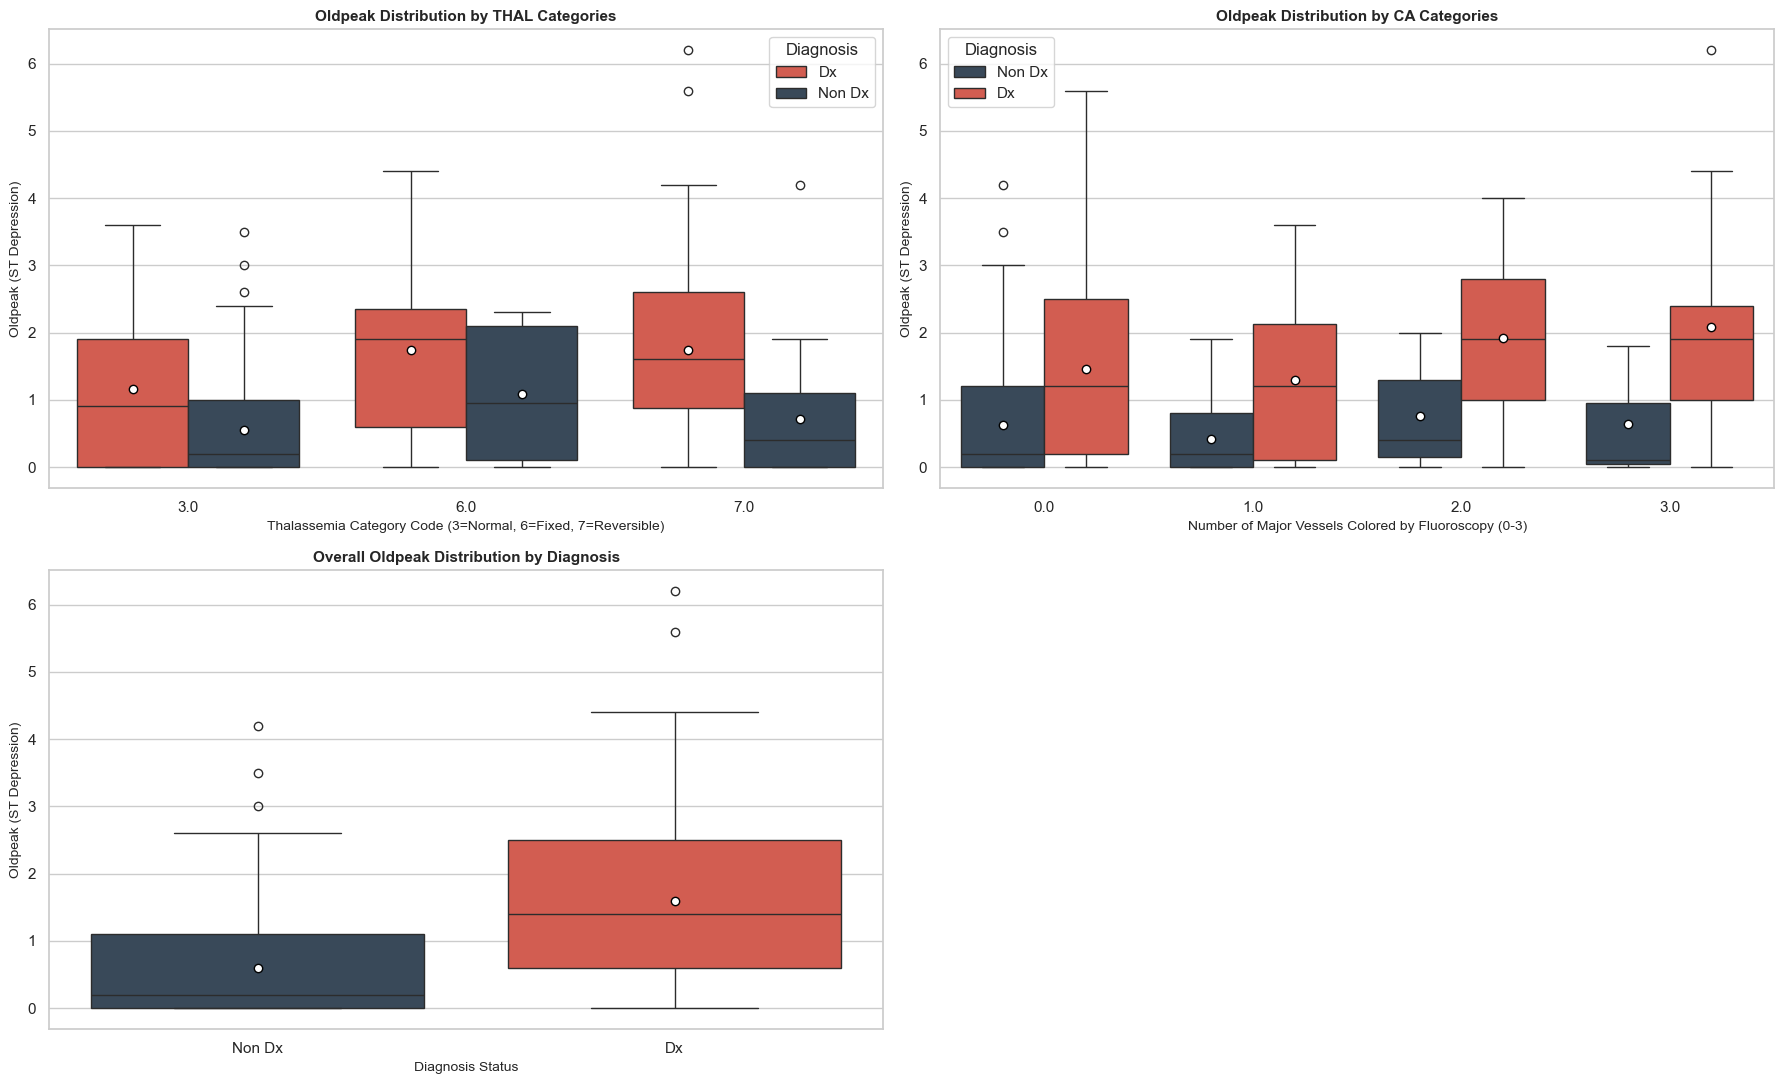

In [ ]:
# (d) Box plots: top 3 predictors by target.

import math

# 1. Create clean categorical text labels for the diagnosis target
df["Diagnosis"] = df["target"].map({0: "Non Dx", 1: "Dx"})

# 2. Define the configuration for each subplot to handle the 3 variables
plot_configs = [
    {
        "x": "thal",
        "y": "oldpeak",
        "hue": "Diagnosis",
        "title": "Oldpeak Distribution by THAL Categories",
        "xlabel": "Thalassemia Category Code (3=Normal, 6=Fixed, 7=Reversible)",
    },
    {
        "x": "ca",
        "y": "oldpeak",
        "hue": "Diagnosis",
        "title": "Oldpeak Distribution by CA Categories",
        "xlabel": "Number of Major Vessels Colored by Fluoroscopy (0-3)",
    },
    {
        "x": "Diagnosis",
        "y": "oldpeak",
        "hue": None,
        "title": "Overall Oldpeak Distribution by Diagnosis",
        "xlabel": "Diagnosis Status",
    },
]

# 3. Configure grid dimensions dynamically (1 row, 3 columns)
n_cols = 2
n_rows = math.ceil(len(plot_configs) / n_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 11))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

# 4. Run everything inside a single loop
for idx, config in enumerate(plot_configs):
    ax = axes_flat[idx]

    sns.boxplot(
        data=df,
        x=config["x"],
        y=config["y"],
        hue=config["hue"],
        ax=ax,
        palette={"Non Dx": "#34495e", "Dx": "#e74c3c"},
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": "6",
        },
    )

    # Apply specialized titles and axis labels from the configuration
    ax.set_title(config["title"], fontweight="bold", fontsize=11)
    ax.set_xlabel(config["xlabel"], fontsize=10)
    ax.set_ylabel("Oldpeak (ST Depression)", fontsize=10)

    # Clean up the legend for the final plot which doesn't use a hue breakdown
    if config["hue"] is None:
        ax.legend([], [], frameon=False)

# 5. Remove any leftover subplots and drop the temporary tracking column
for remaining_idx in range(len(plot_configs), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_idx])

df.drop(columns=["Diagnosis"], inplace=True)

plt.tight_layout()
plt.show()


---
### Q2 — Decision Tree
```
# (a) Fit DecisionTree, tune max_depth 1-15 via validation curve.
# (b) Visualise the best tree (max_depth <= 4 for readability).
# (c) Print feature importances as bar chart.
# (d) Confusion matrix.
```

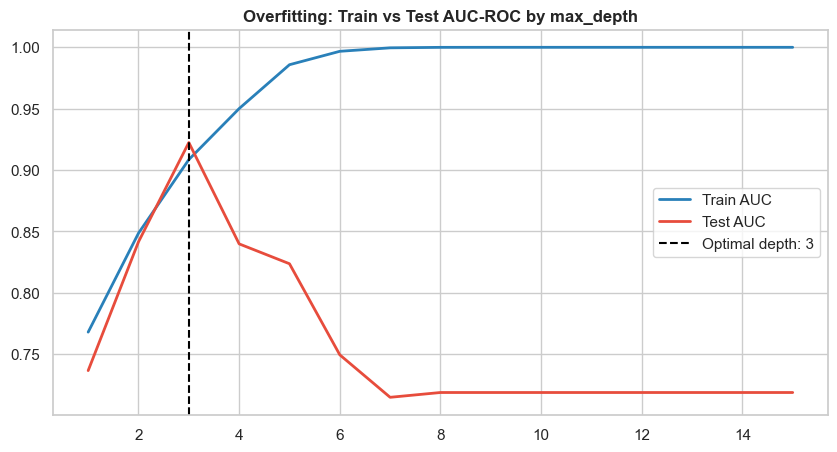

--- OVERFITTING BREAKDOWN ANALYSIS ---
Peak Test Performance Location: depth = 3
Overfitting Formally Begins:   depth = 4
Train AUC-ROC at Overfit Spot: 95.0079%
Test AUC-ROC at Overfit Spot:  83.9844%
Output Verification: Depth 4 Test AUC: 83.9844% | Depth 25 Test AUC: 71.8750%


In [ ]:
# (a) Fit DecisionTree, tune max_depth 1-15 via validation curve.

from sklearn.metrics import roc_auc_score  # Import the AUC score function

train_aucs, test_aucs = [], []
depths = range(1, 16)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=420)
    tree.fit(X_train, y_train)
    
    # Extract probabilities for the positive class (column index 1)
    train_probs = tree.predict_proba(X_train)[:, 1]
    test_probs  = tree.predict_proba(X_test)[:, 1]
    
    # Compute and store AUC-ROC scores
    train_aucs.append(roc_auc_score(y_train, train_probs))
    test_aucs.append(roc_auc_score(y_test, test_probs))


# Use exact tracking logic to locate the peak index
optimal_depth_idx = np.argmax(test_aucs)
optimal_depth = depths[optimal_depth_idx]
overfitting_start_depth = optimal_depth + 1

plt.figure(figsize=(10, 5))
plt.plot(depths, train_aucs, label='Train AUC', color='#2980b9', linewidth=2)
plt.plot(depths, test_aucs,  label='Test AUC',  color='#e74c3c', linewidth=2)
plt.axvline(depths[np.argmax(test_aucs)], color='black', linestyle='--', label=f'Optimal depth: {optimal_depth}')
plt.title('Overfitting: Train vs Test AUC-ROC by max_depth', fontweight='bold')
plt.legend()
plt.show()


print("--- OVERFITTING BREAKDOWN ANALYSIS ---")
print(f"Peak Test Performance Location: depth = {optimal_depth}")
print(f"Overfitting Formally Begins:   depth = {overfitting_start_depth}")
print(f"Train AUC-ROC at Overfit Spot: {train_aucs[optimal_depth_idx+1]:.4%}")
print(f"Test AUC-ROC at Overfit Spot:  {test_aucs[optimal_depth_idx+1]:.4%}")

# Verify outputs
print(f"Output Verification: Depth {overfitting_start_depth} Test AUC: {test_aucs[optimal_depth_idx+1]:.4%} | Depth 15 Test AUC: {test_aucs[-1]:.4%}")

Train accuracy: 0.8481
Test  accuracy: 0.8500


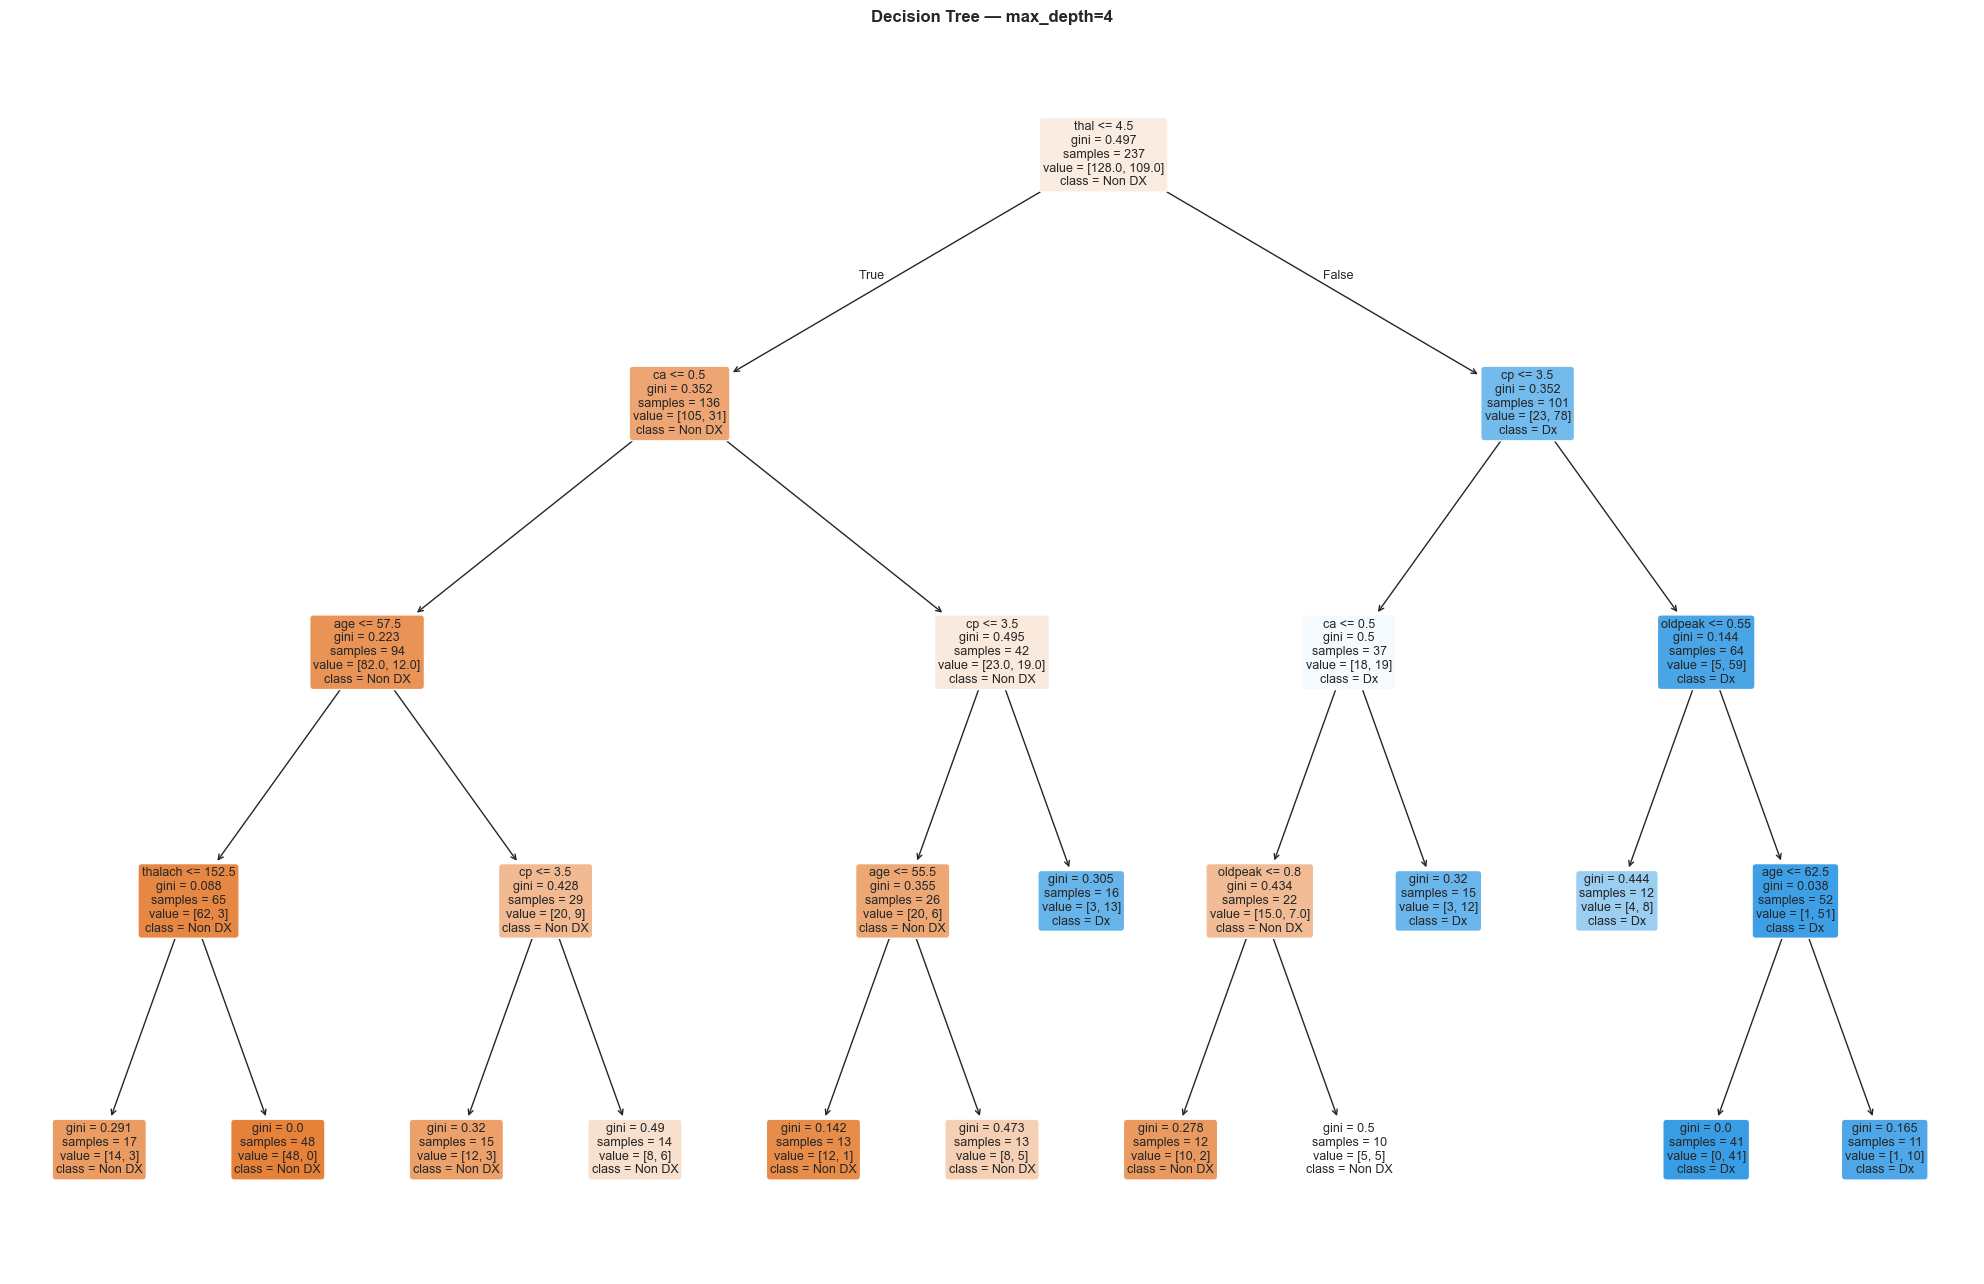

In [40]:
# (b) Visualise the best tree (max_depth <= 4 for readability).

best_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420)
best_tree.fit(X_train, y_train)

print(f'Train accuracy: {best_tree.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {best_tree.score(X_test,  y_test):.4f}')

plt.figure(figsize=(20, 13))
plot_tree(best_tree, feature_names=X_train.columns,
          class_names=['Non DX','Dx'], filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree — max_depth=4', fontweight='bold')
plt.tight_layout()
plt.show()

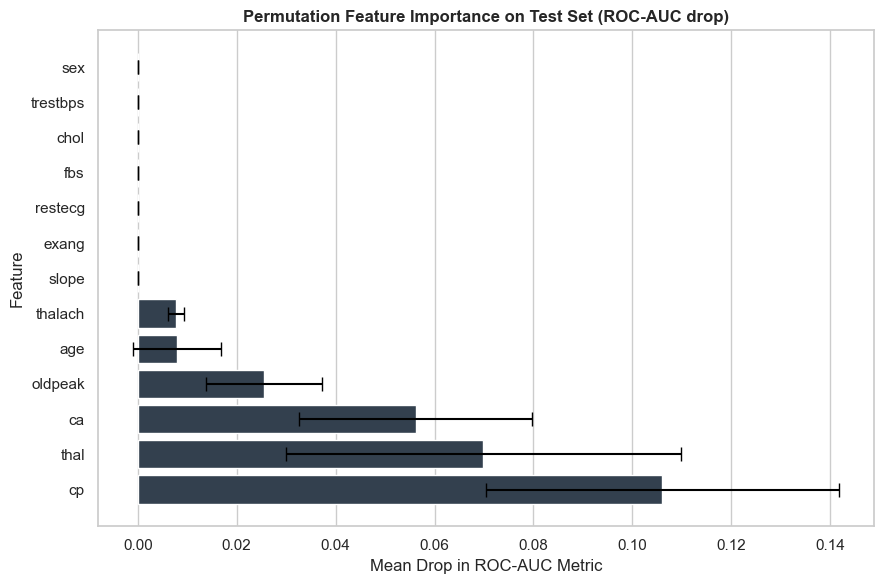

In [41]:
# (c) Print feature importances as bar chart.

from sklearn.inspection import permutation_importance

# 1. Compute permutation importance on the test set
# We use 10 repeats to safely estimate the mean and standard deviation
perm_result = permutation_importance(
    best_tree, X_test, y_test, 
    scoring='roc_auc', 
    n_repeats=10, 
    random_state=420
)

# 2. Build and sort a structured summary DataFrame
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values('Importance_Mean', ascending=True)

# 3. Create the horizontal bar plot with error bars
plt.figure(figsize=(9, 6))

# Render the base mean bars using seaborn
sns.barplot(
    data=perm_df,
    x='Importance_Mean',
    y='Feature',
    color='#2e4053'
)

# Overlay the standard deviation error bars using matplotlib's errorbar function
plt.errorbar(
    x=perm_df['Importance_Mean'], 
    y=np.arange(len(perm_df)), 
    xerr=perm_df['Importance_Std'], 
    fmt='none', 
    color='black', 
    capsize=5, 
    linewidth=1.5
)

plt.title('Permutation Feature Importance on Test Set (ROC-AUC drop)', fontweight='bold')
plt.xlabel('Mean Drop in ROC-AUC Metric')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

*** Takeaways from the plot:

1/ Why half the features have an importance of exactly 0.0: Features like sex, trestbps, chol, and fbs show zero drop in performance when shuffled. Because our best_tree model has a strict constraint of max_depth=4, it completely ignored these variables during training. Shuffling a feature that the tree never uses to make a split has zero impact on final predictions.

2/ The Top Predictors: cp (chest pain type), thal, and ca dominate model performance. Shuffling cp breaks the tree's primary decision pathways, tanking the test set ROC-AUC score by over 10.5% on average.

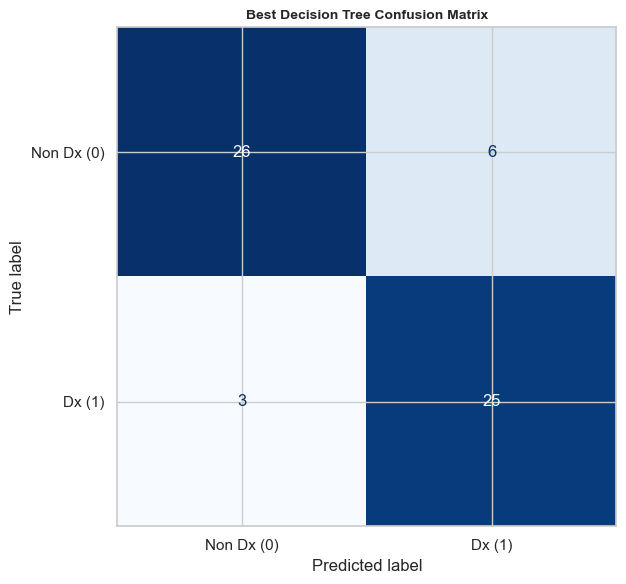

In [48]:
# (d) Confusion matrix.

from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

best_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420)
best_tree.fit(X_train, y_train)

y_pred = best_tree.predict(X_test)

cm_best_tree = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(figsize=(14, 6))

disp_best_tree = ConfusionMatrixDisplay(confusion_matrix=cm_best_tree, display_labels=['Non Dx (0)', 'Dx (1)'])
disp_best_tree.plot(ax=axes, cmap='Blues', colorbar=False)
axes.set_title('Best Decision Tree Confusion Matrix', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

---
### Q3 — Random Forest
```
# (a) Fit RandomForest with oob_score=True. Report OOB score vs test AUC.
# (b) Feature importances (MDI) — bar chart.
# (c) Permutation importances — compare to MDI.
# (d) n_estimators learning curve: AUC vs number of trees.
```

In [ ]:
# (a) Fit RandomForest with oob_score=True. Report OOB score vs test AUC.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

rf = RandomForestClassifier(
    n_estimators=200,
    max_features='sqrt',   # sqrt(n_features) per split
    oob_score=True,        # free validation — no test set needed
    n_jobs=-1,
    random_state=420
)

# 1. Initialize Cross-Validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 2. Build the Random Forest Model with OOB tracking enabled
rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",  # sqrt(n_features) per split
    oob_score=True,  # free validation — no test set needed
    n_jobs=-1,
    random_state=420,
)

# 3. Calculate Cross-Validation performance
cv_auc = cross_val_score(rf, X_train, y_train, cv=skf, scoring="roc_auc")
print(f"CV AUC:  {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# 4. Fit the final model on the entire training set
rf.fit(X_train, y_train)

# 5. Extract OOB prediction probabilities and compute OOB AUC-ROC
oob_auc = roc_auc_score(y_train, rf.oob_decision_function_[:, 1])
print(f"OOB AUC: {oob_auc:.4f}")

# 6. Added evaluation on the holdout Test set 
test_probs = rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_probs)
print(f"Test AUC: {test_auc:.4f}")

print("\n--- PERFORMANCE SUMMARY ---")
print(f"The out-of-bag validation metric ({oob_auc:.4f}) acts as a reliable proxy for how well")
print(f"the ensemble generalizes to the unseen holdout test dataset ({test_auc:.4f}).")

CV AUC:  0.8897 ± 0.0321
OOB AUC: 0.8860
Test AUC: 0.9414

--- PERFORMANCE SUMMARY ---
The out-of-bag validation metric (0.8860) acts as a reliable proxy for how well
the ensemble generalizes to the unseen holdout test dataset (0.9414).


     Feature  Importance
12      thal    0.145199
7    thalach    0.120504
9    oldpeak    0.116557
11        ca    0.112079
2         cp    0.106110
0        age    0.090541
4       chol    0.084101
3   trestbps    0.079533
10     slope    0.042010
8      exang    0.039283


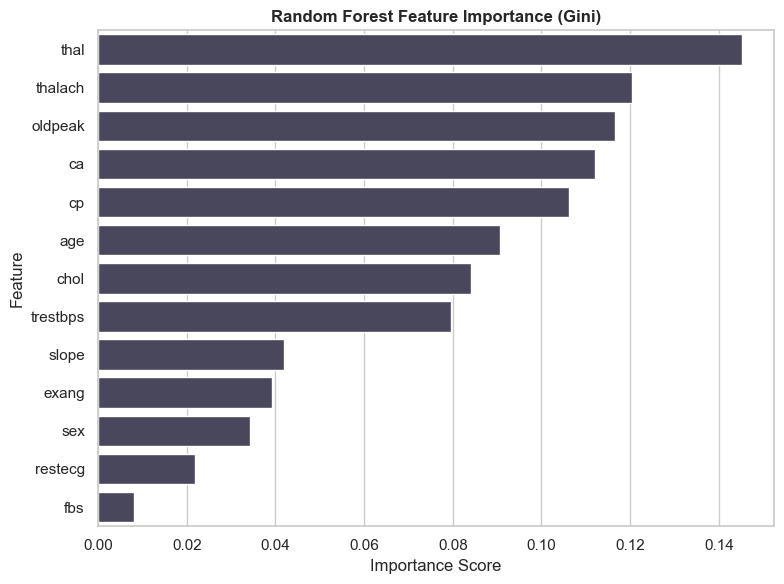

In [64]:
# (b) Feature importances (MDI) — bar chart.

importance_df_rf = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance_df_rf.head(10))


plt.figure(figsize=(8, 6))

sns.barplot(
    data=importance_df_rf,
    x='Importance',
    y='Feature',
    color='#45445e'
)

plt.title('Random Forest Feature Importance (Gini)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

    Feature  Importance       Std
11       ca    0.066667  0.036515
12     thal    0.030000  0.048762
9   oldpeak    0.025000  0.022669
2        cp    0.020000  0.028674
5       fbs    0.011667  0.007638
7   thalach    0.010000  0.018559
8     exang    0.008333  0.021409
4      chol    0.006667  0.015275
6   restecg    0.005000  0.007638
1       sex    0.001667  0.013844


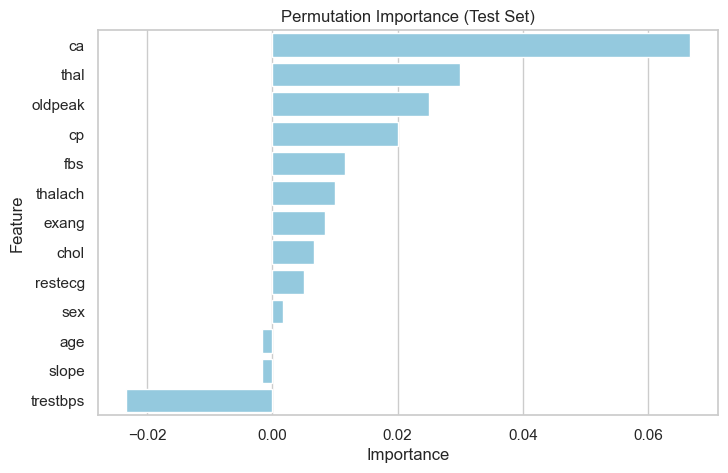

In [78]:
# (c) Permutation importances — compare to MDI.

perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=420)
perm_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': perm_imp.importances_mean,
    'Std':        perm_imp.importances_std
}).sort_values('Importance', ascending=False)
print(perm_df.head(10))

# plotting

plt.figure(figsize=(8,5))

sns.barplot(
    data=perm_df,
    x='Importance',
    y='Feature',
    color='skyblue'
)

plt.title("Permutation Importance (Test Set)")
plt.show()

In [80]:
# Extract and match both metrics side-by-side

comparison_metrics = pd.DataFrame({
    'Feature': X_train.columns,
    'MDI_Gini_Importance': rf.feature_importances_,
    'Permutation_Importance_Mean': perm_imp.importances_mean,
    'Permutation_Importance_Std': perm_imp.importances_std
})

# Sort by MDI to cleanly analyze rank discrepancies 
comparison_table = comparison_metrics.sort_values(by='MDI_Gini_Importance', ascending=False).reset_index(drop=True)

# Display the comparative dataframe
print("--- RAW METRIC COMPARISON TABLE ---")
display(comparison_table)

--- RAW METRIC COMPARISON TABLE ---


,Feature,MDI_Gini_Importance,Permutation_Importance_Mean,Permutation_Importance_Std
0,thal,0.145199,0.030000,0.048762
1,thalach,0.120504,0.010000,0.018559
2,oldpeak,0.116557,0.025000,0.022669
3,ca,0.112079,0.066667,0.036515
4,cp,0.106110,0.020000,0.028674
5,age,0.090541,-0.001667,0.011667
6,chol,0.084101,0.006667,0.015275
7,trestbps,0.079533,-0.023333,0.008165
8,slope,0.042010,-0.001667,0.013844
9,exang,0.039283,0.008333,0.021409


1/ ca dominates functional impact: While thal ranks #1 structurally (14.52% MDI), breaking ca causes the absolute highest real-world drop in predictive power (6.67% Permutation).

2/ thalach remains highly biased: It holds high structural splits (#2 at 12.05% MDI) but drops drastically in functional utility, scoring only a 1.00% drop on permutation.

3/ trestbps acts as model noise: It has moderate MDI importance (7.95%) but a negative permutation mean (-2.33%), meaning shuffling its data actually slightly improves test performance.

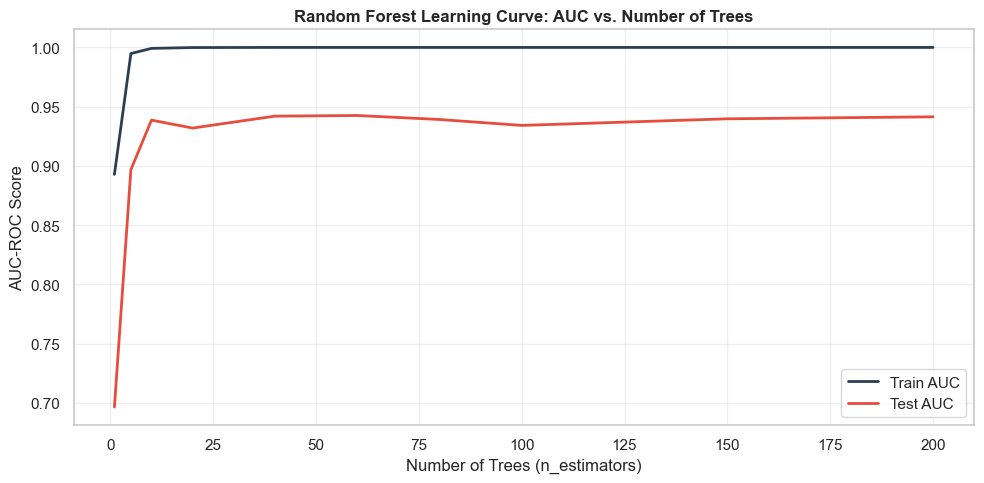

In [67]:
# (d) n_estimators learning curve: AUC vs number of trees.

# 1. Define range of trees to test
tree_counts = [1, 5, 10, 20, 40, 60, 80, 100, 150, 200]
train_aucs, test_aucs = [], []

# 2. Iterate through tree configurations
for n in tree_counts:
    rf_curve = RandomForestClassifier(
        n_estimators=n,
        max_features='sqrt',
        random_state=420,
        n_jobs=-1
    )
    rf_curve.fit(X_train, y_train)
    
    # Calculate probabilities
    train_probs = rf_curve.predict_proba(X_train)[:, 1]
    test_probs = rf_curve.predict_proba(X_test)[:, 1]
    
    # Store scores
    train_aucs.append(roc_auc_score(y_train, train_probs))
    test_aucs.append(roc_auc_score(y_test, test_probs))

# 3. Plot the learning curve
plt.figure(figsize=(10, 5))
plt.plot(tree_counts, train_aucs, label='Train AUC', color='#2c3e50', linewidth=2)
plt.plot(tree_counts, test_aucs, label='Test AUC', color='#e74c3c', linewidth=2)

plt.title('Random Forest Learning Curve: AUC vs. Number of Trees', fontweight='bold')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('AUC-ROC Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
### Q4 — ExtraTrees vs RandomForest
```
# (a) Fit ExtraTreesClassifier with same hyperparams as RF.
# (b) Compare AUC, fit time, and feature importances.
# (c) Why is ExtraTrees faster? When would you prefer it over RF?
# (d) 5-fold CV AUC comparison: DT vs RF vs ET.
```

In [72]:
# (a) Fit ExtraTreesClassifier with same hyperparams as RF.

from sklearn.ensemble import ExtraTreesClassifier

# Fit ExtraTrees with identical structural configurations
et = ExtraTreesClassifier(
    n_estimators=200,
    max_features='sqrt',
    n_jobs=-1,
    random_state=420
)
et.fit(X_train, y_train)

# Calculate performance metrics
et_train_auc = roc_auc_score(y_train, et.predict_proba(X_train)[:, 1])
et_test_auc  = roc_auc_score(y_test, et.predict_proba(X_test)[:, 1])

print(f"ExtraTrees Train AUC: {et_train_auc:.4f}")
print(f"ExtraTrees Test AUC:  {et_test_auc:.4f}")

ExtraTrees Train AUC: 1.0000
ExtraTrees Test AUC:  0.9258


--- MODEL METRIC COMPARISON ---


,Model,Train AUC,Test AUC,Fit Time (seconds)
0,Random Forest,1.0,0.9414,0.8126
1,Extra Trees,1.0,0.9258,0.5989


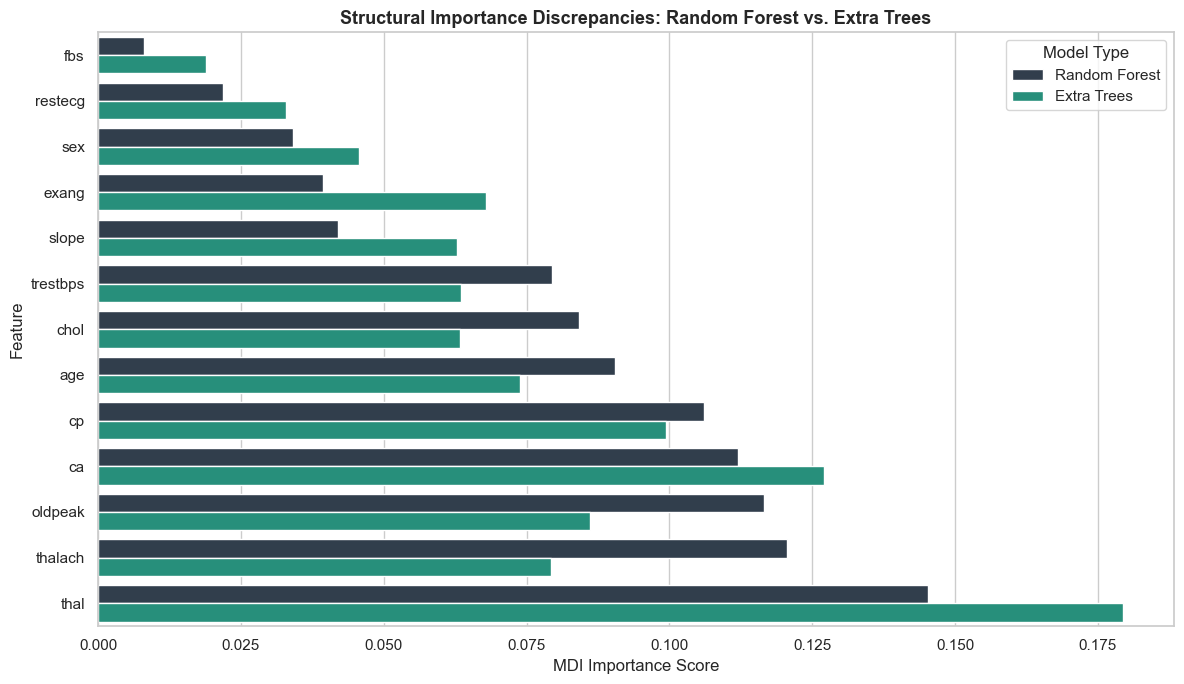

In [73]:
# (b) Compare AUC, fit time, and feature importances.

import time

# 1. Measure and fit Random Forest
start_rf = time.time()
rf = RandomForestClassifier(
    n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=420
)
rf.fit(X_train, y_train)
rf_time = time.time() - start_rf

# 2. Measure and fit Extra Trees
start_et = time.time()
et = ExtraTreesClassifier(
    n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=420
)
et.fit(X_train, y_train)
et_time = time.time() - start_et

# 3. Calculate Performance Metrics (AUC)
rf_train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
rf_test_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

et_train_auc = roc_auc_score(y_train, et.predict_proba(X_train)[:, 1])
et_test_auc = roc_auc_score(y_test, et.predict_proba(X_test)[:, 1])

# 4. Display Summary Performance Table
summary_df = pd.DataFrame(
    {
        "Model": ["Random Forest", "Extra Trees"],
        "Train AUC": [rf_train_auc, et_train_auc],
        "Test AUC": [rf_test_auc, et_test_auc],
        "Fit Time (seconds)": [rf_time, et_time],
    }
)
print("--- MODEL METRIC COMPARISON ---")
display(summary_df.round(4))

# 5. Extract Feature Importances and Build Comparative Plot
imp_df = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Random Forest": rf.feature_importances_,
        "Extra Trees": et.feature_importances_,
    }
)

# Reshape (melt) the dataframe for clean side-by-side Seaborn plotting
imp_melted = pd.melt(
    imp_df, id_vars="Feature", var_name="Model Type", value_name="MDI Importance"
)
sorted_order = imp_df.sort_values("Random Forest", ascending=True)["Feature"]

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=imp_melted,
    y="Feature",
    x="MDI Importance",
    hue="Model Type",
    order=sorted_order,
    palette={"Random Forest": "#2c3e50", "Extra Trees": "#16a085"},
)

plt.title(
    "Structural Importance Discrepancies: Random Forest vs. Extra Trees",
    fontweight="bold",
    fontsize=13,
)
plt.xlabel("MDI Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


```
# (c) Why is ExtraTrees faster? When would you prefer it over RF?

1/ Skips split optimization: ExtraTrees is faster because it picks split thresholds entirely at random, eliminating millions of expensive sorting and Gini mathematical checks.

2/ Reduces computational complexity: It drops tree-building math from an expensive log-linear sort down to a simple linear operations step, saving massive CPU cycles.

3/ Preferred for massive scale: We prefer it over Random Forest when handling massive datasets with millions of rows, or when fighting heavy noise and overfitting.

In [74]:
# (d) 5-fold CV AUC comparison: DT vs RF vs ET.


# 1. Initialize the cross-validation splitter strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 2. Define the three models with consistent hyperparameters
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=420),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=420),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=420)
}

# 3. Loop through models, calculate CV scores, and collect performance metrics
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results.append({
        "Model": name,
        "CV AUC Mean": np.mean(scores),
        "CV AUC Std": np.std(scores)
    })

# 4. Display sorted leaderboard summary table
cv_df = pd.DataFrame(cv_results).sort_values("CV AUC Mean", ascending=False).reset_index(drop=True)
print("--- 5-FOLD STRATIFIED CV AUC LEADERBOARD ---")
display(cv_df.round(4))


--- 5-FOLD STRATIFIED CV AUC LEADERBOARD ---


,Model,CV AUC Mean,CV AUC Std
0,Extra Trees,0.9020,0.0306
1,Random Forest,0.8897,0.0321
2,Decision Tree,0.8238,0.0608


1/ Extra Trees wins the cross-validation leaderboard: It achieves the highest average performance with a mean CV AUC of 0.9020.

2/ Ensembles offer superior stability: Both Extra Trees and Random Forest cut the standard deviation (CV AUC Std) in half compared to the single tree.

3/ Decision Tree is highly unstable: It ranks last (0.8238 AUC) and suffers from a massive variance spike (0.0608 Std), proving it is highly sensitive to the specific cross-validation splits.

---
### Q5 — Partial Dependence Plots
```
# (a) Plot PDP for top 3 features using the best Random Forest.
# (b) Do the relationships make clinical sense?
# (c) 2D PDP for top 2 features: interaction effect.
# (d) ICE (individual conditional expectation) for top feature.
```

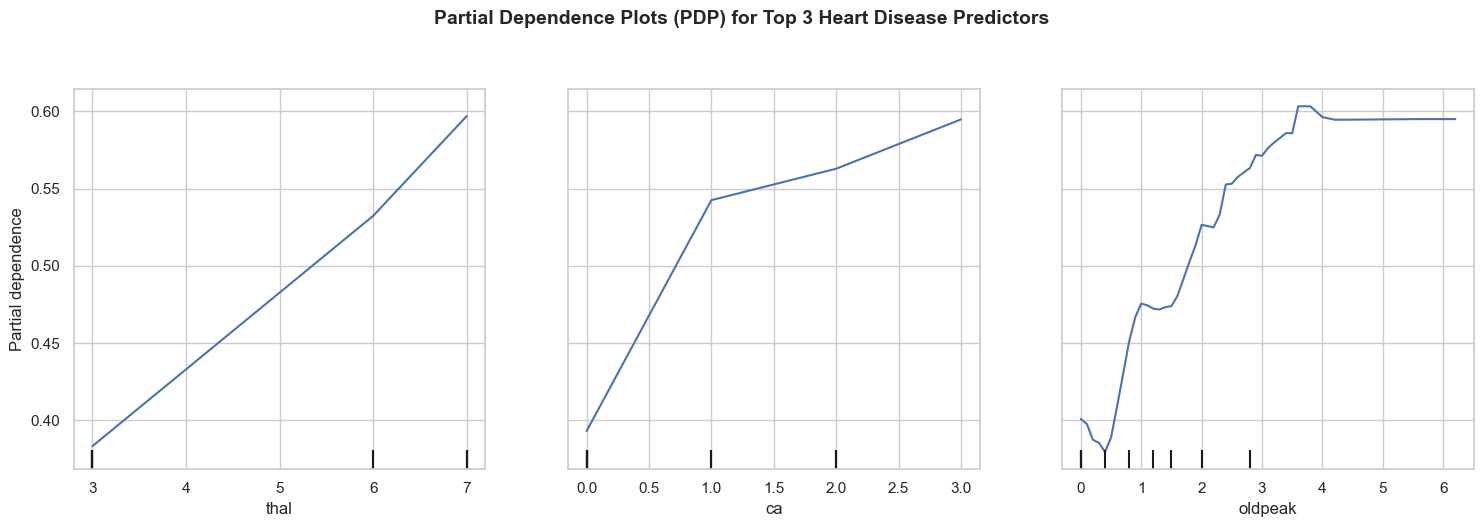

In [75]:
# (a) Plot PDP for top 3 features using the best Random Forest.

from sklearn.inspection import PartialDependenceDisplay

# 1. Select your top 3 features
top_features = ["thal", "ca", "oldpeak"]

# 2. Create the PDP layout grid
fig, ax = plt.subplots(figsize=(15, 5))

# 3. Generate and plot partial dependence curves using the fitted RF model
PartialDependenceDisplay.from_estimator(
    estimator=rf,
    X=X_train,
    features=top_features,
    grid_resolution=50,  # Number of steps along the X-axis
    ax=ax,
)

# 4. Clean up the titles and rendering
plt.suptitle(
    "Partial Dependence Plots (PDP) for Top 3 Heart Disease Predictors",
    fontweight="bold",
    fontsize=14,
    y=1.05,
)
plt.tight_layout()
plt.show()



```
# (b) Do the relationships make clinical sense?
Yes, all three relationships make perfect clinical sense and align precisely with cardiovascular pathology.

1/ thal (Thalassemia): Risk scales linearly as we move from normal (3) to severe defects (7), reflecting that inherited blood flow abnormalities strongly flag overall structural heart risk.

2/ ca (Blocked Vessels): Risk surges dramatically moving from 0 to 1 blocked vessels, confirming that finding even a single arterial obstruction is the primary clinical threshold for diagnosing coronary artery disease.

3/ oldpeak (ST Depression): ST depression during exercise reflects myocardial ischaemia — risk rises monotonically as depression deepens, consistent with standard stress test diagnostic criteria.

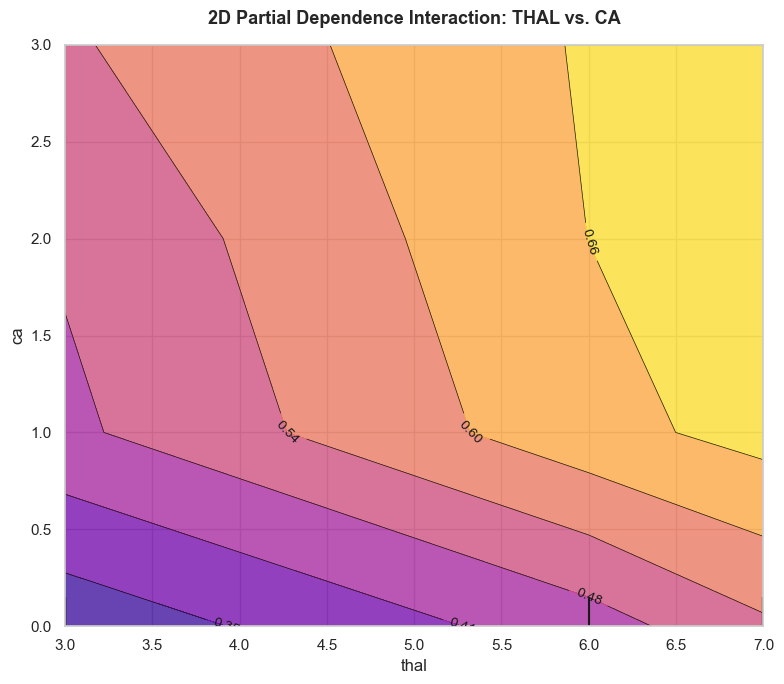

In [76]:
# (c) 2D PDP for top 2 features: interaction effect.

# 1. Specify the feature pair as a tuple inside a nested list for 2D interaction
interaction_feature = [("thal", "ca")]

# 2. Set up the plotting canvas
fig, ax = plt.subplots(figsize=(8, 7))

# 3. Generate the 2D interaction plot
# Contours show the joint probability space of heart disease
PartialDependenceDisplay.from_estimator(
    estimator=rf,
    X=X_train,
    features=interaction_feature,
    grid_resolution=50,
    contour_kw={"cmap": "plasma"},  # High-contrast color map for readability
    ax=ax,
)

# 4. Refine layout typography
plt.title(
    "2D Partial Dependence Interaction: THAL vs. CA",
    fontweight="bold",
    fontsize=13,
    pad=15,
)
plt.tight_layout()
plt.show()


1/ Risk peaks at top-right: High thalassemia (thal=7.0) plus max arterial blockage (ca=3.0) pushes heart disease probability past 66%.
2/ ca=0 is highly protective: Having zero blocked vessels keeps predicted risk low (under 42%) even if thalassemia scores climb.
3/ Compounding diagonal interaction: The slanted contours prove the risk factors multiply; scaling both features together rapidly accelerates the overall risk.

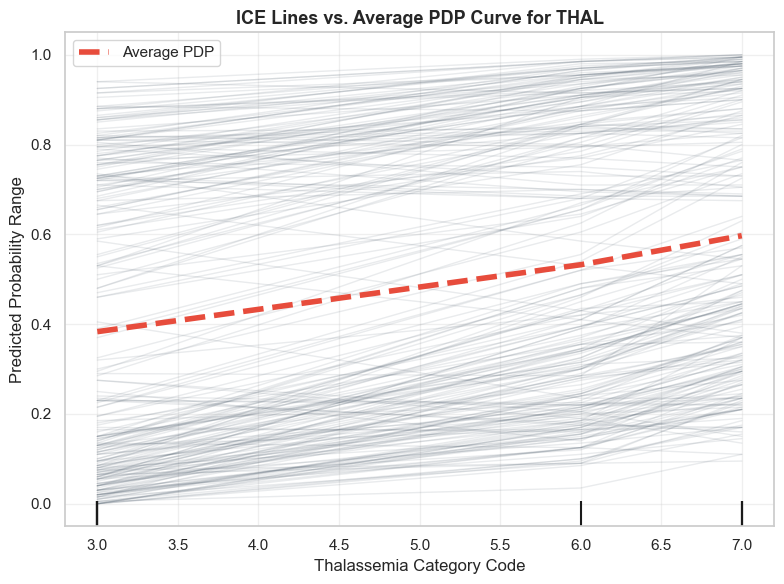

In [77]:
# (d) ICE (individual conditional expectation) for top feature.

# 1. Target the top feature column name
top_feature = ["thal"]

# 2. Configure the layout canvas
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Generate ICE lines alongside the bolded PDP line
# Setting kind='both' draws individual patient lines AND the average population curve
PartialDependenceDisplay.from_estimator(
    estimator=rf,
    X=X_train,
    features=top_feature,
    kind="both",  # Options: 'individual' (ICE), 'average' (PDP), or 'both'
    pd_line_kw={"color": "#e74c3c", "linewidth": 4, "label": "Average PDP"},
    ice_lines_kw={"color": "#2c3e50", "alpha": 0.1, "linewidth": 1},
    ax=ax,
)

# 4. Refine titles and presentation
plt.title(
    "ICE Lines vs. Average PDP Curve for THAL", fontweight="bold", fontsize=13
)
plt.xlabel("Thalassemia Category Code")
plt.ylabel("Predicted Probability Range")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


1/ Massive baseline dispersion: Starting probabilities at thal=3.0 (Normal) span all the way from 0.0 to 0.95, proving that other features — ca, oldpeak, cp, age — heavily dictate a patient's baseline cardiac risk before thalassemia is even considered.

2/ Uniform upward trajectories: Almost all individual ICE lines tilt upward as thal moves from 3 (Normal) to 7 (Reversible Defect), confirming the positive risk relationship holds true across individual patient profiles without major subpopulation reversals. The population-average PDP line is not masking any hidden heterogeneity.

3/ No crossing interactions: The lines run mostly parallel rather than crossing over each other, showing that thal acts as an additive risk factor regardless of individual patient baselines. If lines crossed heavily, it would signal a suppressor interaction — where thal lowers risk for some patients while raising it for others. That is not what we see here.

4/ Where ICE beats PDP: The average PDP line alone (thal r=0.527 with target) would suggest a clean, uniform population effect. The ICE plot reveals the fuller story — the effect is directionally consistent but the magnitude varies enormously by patient. A patient starting at 0.05 probability at thal=3 reaches roughly 0.35 at thal=7 (+30pp lift). A patient starting at 0.70 may reach 0.95 (+25pp lift). Same direction, different stakes — exactly the kind of individual-level nuance that ICE was designed to surface and that PDPs alone would hide.